# **MET Computer Vision with Deep Learning**
## Visual Recognition
## Lab3 - Semantic Segmentation with U-Net

2025 - Veronica Vilaplana - [GPI @ IDEAI](https://imatge.upc.edu/web/) Research group // [ETSETB – UPC.TelecosBCN](https://telecos.upc.edu/ca)

In [2]:
!pip install -q segmentation-models-pytorch albumentations==1.3.0 torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.5/123.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 48.1 MB/s eta 0:00:00


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import OxfordIIITPet
from segmentation_models_pytorch.losses import DiceLoss
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import os
from tqdm import tqdm


In [4]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device in use:", device)
if device.type == "cpu":
    print("WARNING: You are using CPU. Consider switching to GPU in Runtime > Change runtime type.")


Device in use: cuda


## Load Dataset and Prepare Train/Test Splits

In [4]:
dataset = OxfordIIITPet(root="./data", download=True, target_types="segmentation")

def convert_mask(mask):
    mask = np.array(mask)
    mask = (mask > 1).astype(np.uint8)
    return mask

class PetSegmentationDataset(Dataset):
    def __init__(self, base_ds, indices, transform=None):
        self.base_ds = base_ds
        self.indices = indices
        self.transform = transform

    def __getitem__(self, idx):
        image, mask = self.base_ds[self.indices[idx]]
        image = np.array(image)
        mask = convert_mask(mask)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].long()
        return image, mask

    def __len__(self):
        return len(self.indices)

# Create train/test splits
indices = list(range(len(dataset)))
np.random.seed(42)
np.random.shuffle(indices)
train_indices = indices[:200]
test_indices = indices[200:250]



# Train transforms
train_transform = A.Compose([
    A.Resize(128, 128),
    A.Normalize(),
    ToTensorV2()
])

# Train transforms
test_transform = A.Compose([
    A.Resize(128, 128),
    A.Normalize(),
    ToTensorV2()
])

train_ds = PetSegmentationDataset(dataset, train_indices, transform=train_transform)
test_ds = PetSegmentationDataset(dataset, test_indices, transform=test_transform)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8)


100%|██████████| 792M/792M [00:36<00:00, 22.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 9.84MB/s]


## Visualize Original images and Augmentations (Outside of Training)

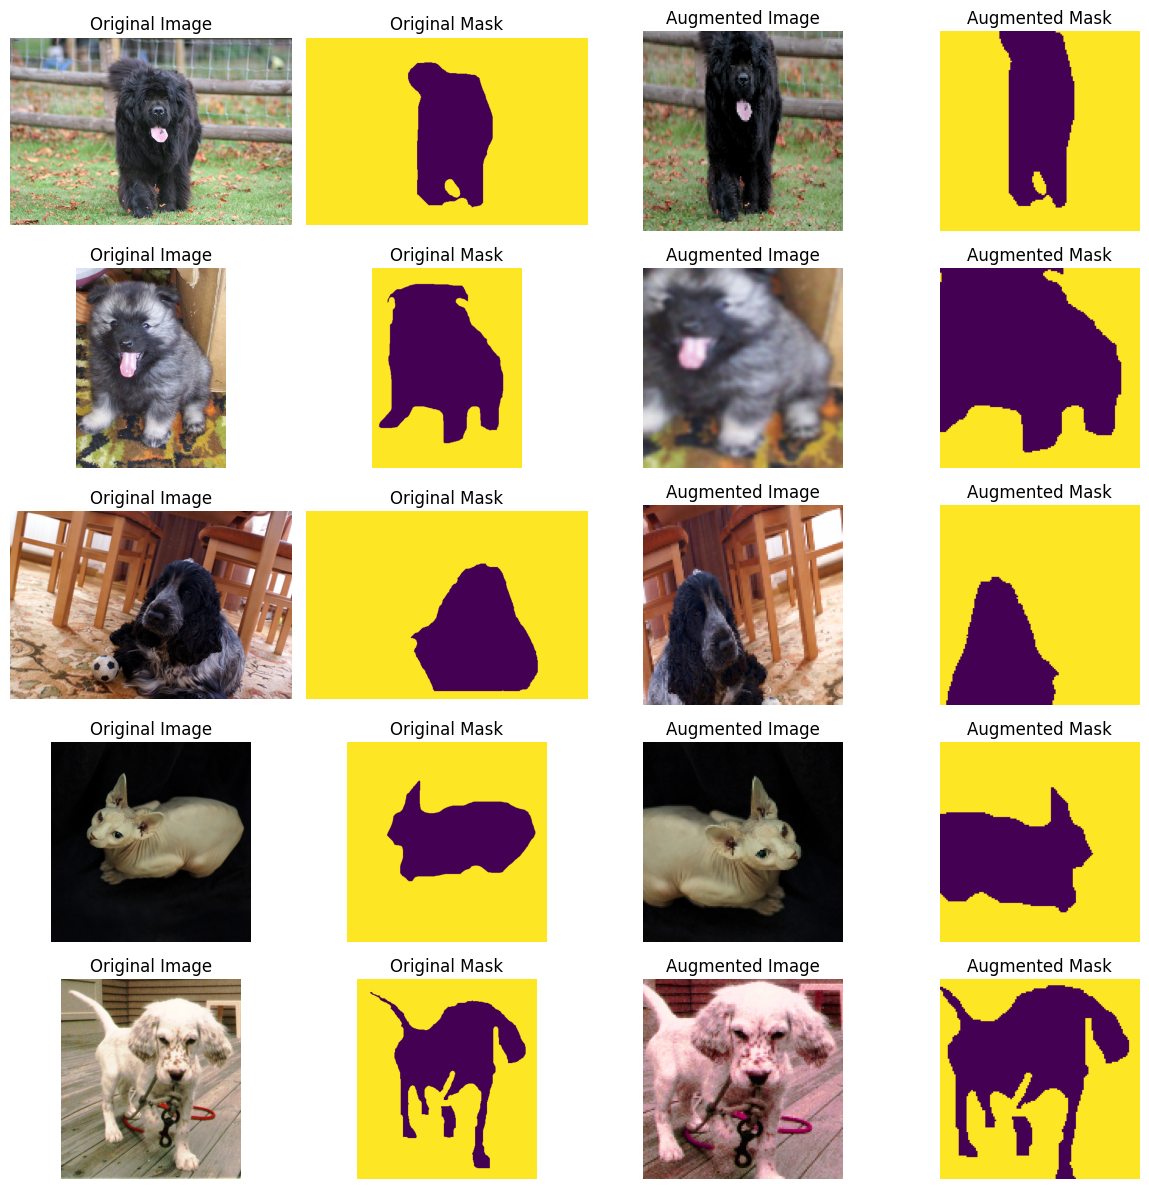

In [9]:
# Visualize with a slightly more augmented transform
# This transformation pipeline includes additional augmentations that are commonly used
# to increase dataset diversity by altering color, intensity, and sharpness. These are NOT
# part of the actual training setup, but are shown here to help you understand what
# advanced augmentations do.

# - Resize(160, 160): scales all images to a slightly larger size, preparing them for cropping.
# - RandomCrop(128, 128): randomly crops a 128x128 region from the resized image.
#   This simulates zooming into different parts of the image during training and introduces
#   positional variability. The model learns to recognize objects regardless of their exact position.
# - HorizontalFlip: flips the image left to right with 50% probability.
# - RandomBrightnessContrast: randomly changes brightness and contrast of the image.
# - HueSaturationValue: randomly changes hue, saturation, and value (HSV space).
# - GaussNoise: adds random Gaussian noise to the image.
# - GaussianBlur: slightly blurs the image to simulate low focus or motion.

# These augmentations are often useful in real-world settings where lighting and noise vary a lot.
# Try experimenting by adding or removing different transformations and seeing their effects.

sample_transform = A.Compose([
    A.Resize(160, 160),
    A.RandomCrop(128, 128),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.HueSaturationValue(p=0.5),
    A.GaussNoise(p=0.3),
    A.GaussianBlur(p=0.2),
    A.Normalize(),
    ToTensorV2()
])

# Visualize original vs augmented image/mask pairs

aug_ds = PetSegmentationDataset(dataset, train_indices, transform=sample_transform)

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
def denormalize(img):
    img = img.permute(1, 2, 0).numpy()
    return (img * std + mean).clip(0, 1)

# Show original and transformed side by side
fig, axs = plt.subplots(5, 4, figsize=(12, 12))

for i in range(5):
    image, mask = dataset[train_indices[i]]
    orig_image = np.array(image)
    orig_mask = convert_mask(mask)

    augmented = sample_transform(image=orig_image, mask=orig_mask)
    aug_image = augmented['image']
    aug_mask = augmented['mask']

    axs[i, 0].imshow(orig_image)
    axs[i, 0].set_title("Original Image")
    axs[i, 1].imshow(orig_mask)
    axs[i, 1].set_title("Original Mask")
    axs[i, 2].imshow(denormalize(aug_image))
    axs[i, 2].set_title("Augmented Image")
    axs[i, 3].imshow(aug_mask)
    axs[i, 3].set_title("Augmented Mask")

    for j in range(4):
        axs[i, j].axis('off')

plt.tight_layout()
plt.show()

## Define U-Net Model and Training Setup

In [10]:
# Create the segmentation model: U-Net with ResNet34 encoder
import segmentation_models_pytorch as smp

model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", classes=2, activation=None)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

## Train the Model

In [11]:
# Simple training loop over 10 epochs (you can increase this number!)
for epoch in range(10):
    model.train()
    running_loss = 0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1} | Loss: {running_loss / len(train_loader):.4f}")


Epoch 1 | Loss: 0.4644
Epoch 2 | Loss: 0.3666
Epoch 3 | Loss: 0.2978
Epoch 4 | Loss: 0.2806
Epoch 5 | Loss: 0.2294
Epoch 6 | Loss: 0.2256
Epoch 7 | Loss: 0.1666
Epoch 8 | Loss: 0.1334
Epoch 9 | Loss: 0.1324
Epoch 10 | Loss: 0.1320


## Evaluate on Test Set (IoU and Dice)

Test mIoU: 0.5721824765205383
Test Dice: 0.7019885182380676


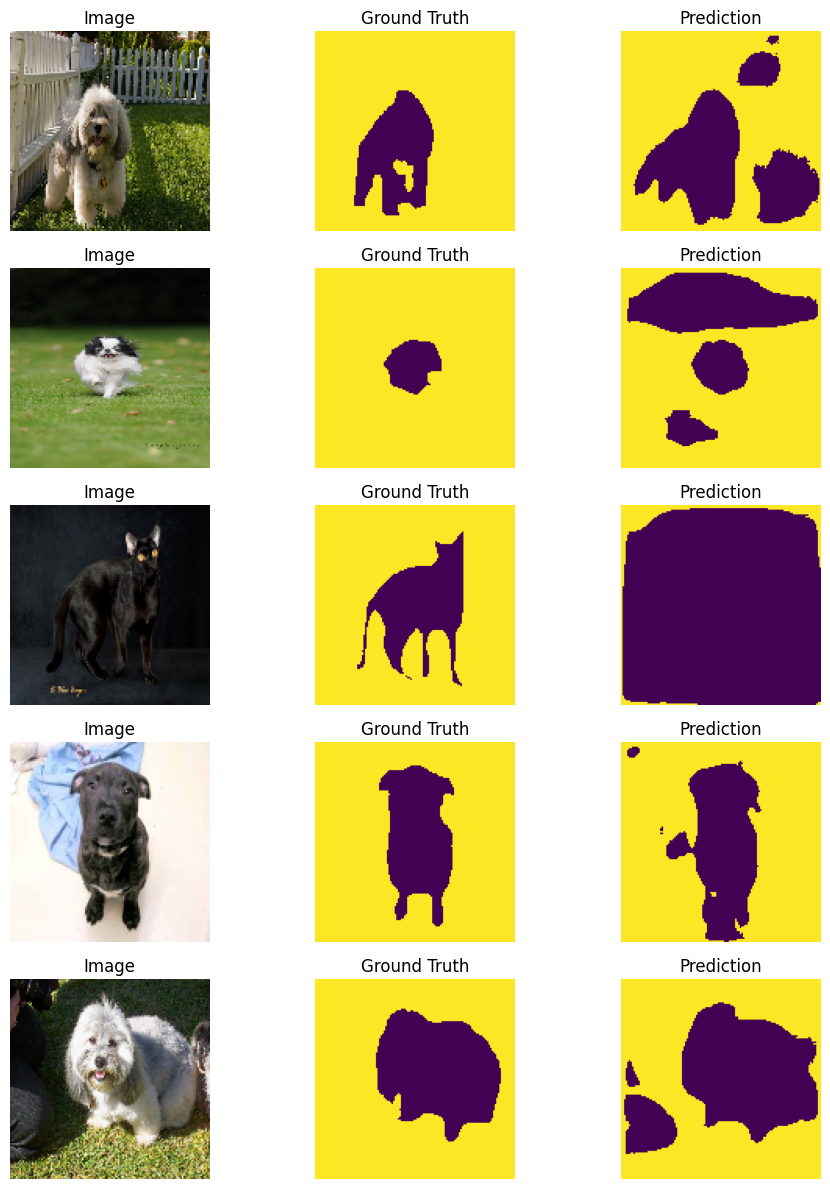

In [12]:
# Evaluate and visualize predictions on a batch of validation data
from torchmetrics import JaccardIndex
from torchmetrics.segmentation import DiceScore

iou = JaccardIndex(task="multiclass", num_classes=2, average="macro").to(device)
dice = DiceScore(num_classes=2, average="macro", input_format="index").to(device)

# Evaluation loop
model.eval()
with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        iou.update(preds, masks)
        dice.update(preds, masks)

# Compute and print metrics
print("Test mIoU:", iou.compute().item())
print("Test Dice:", dice.compute().item())


# Visualize predictions from one test batch
# Denormalization helper (already defined earlier)
def denormalize(img):
    img = img.permute(1, 2, 0).cpu().numpy()
    return (img * std + mean).clip(0, 1)

# Take a batch from the test set
images, masks = next(iter(test_loader))
images = images.to(device)
with torch.no_grad():
    outputs = model(images)
preds = torch.argmax(outputs, dim=1).cpu()

# Plot the first 5 examples
fig, axs = plt.subplots(5, 3, figsize=(10, 12))
for i in range(5):
    axs[i, 0].imshow(denormalize(images[i]))
    axs[i, 0].set_title("Image")
    axs[i, 1].imshow(masks[i])
    axs[i, 1].set_title("Ground Truth")
    axs[i, 2].imshow(preds[i])
    axs[i, 2].set_title("Prediction")
    for j in range(3):
        axs[i, j].axis("off")
plt.tight_layout()
plt.show()


## Tasks

1. Change the encoder from `'resnet34'` to `'efficientnet-b0'`.

2. Replace the loss function with `DiceLoss(mode='binary')`.
   - Note: `DiceLoss` expects **float binary masks** with shape `[B, 1, H, W]`, and model outputs filtered to the foreground channel using `outputs[:, 1:2, :, :]`.
   - Use the following line inside your training loop:
     ```python
     loss = loss_fn(outputs[:, 1:2, :, :], masks.unsqueeze(1).float())
     ```

3. Modify the training transform to include any of the random transformations shown before (section *Visualize Original Images and Augmentations*).

4. Retrain the model with the new setup (you can also change the number of epochs or other hyperparameters in this and in the original experiment)

5. Re-evaluate the model on the test set using IoU and Dice.



# 0) Load Dataset and Prepare Train/Test Splits

In [11]:
dataset = OxfordIIITPet(root="./data", download=True, target_types="segmentation")

def convert_mask(mask):
    mask = np.array(mask)
    mask = (mask > 1).astype(np.uint8)
    return mask

class PetSegmentationDataset(Dataset):
    def __init__(self, base_ds, indices, transform=None):
        self.base_ds = base_ds
        self.indices = indices
        self.transform = transform

    def __getitem__(self, idx):
        image, mask = self.base_ds[self.indices[idx]]
        image = np.array(image)
        mask = convert_mask(mask)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].long()
        return image, mask

    def __len__(self):
        return len(self.indices)

# Create train/test splits
indices = list(range(len(dataset)))
np.random.seed(42)
np.random.shuffle(indices)
train_indices = indices[:200]
test_indices = indices[200:250]



# Train transforms
train_transform = A.Compose([
    A.Resize(128, 128),
    A.Normalize(),
    ToTensorV2()
])

# Train transforms
test_transform = A.Compose([
    A.Resize(128, 128),
    A.Normalize(),
    ToTensorV2()
])

train_ds = PetSegmentationDataset(dataset, train_indices, transform=train_transform)
test_ds = PetSegmentationDataset(dataset, test_indices, transform=test_transform)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8)


# 1) Replace resnet34 for efficientnet-b0

In [12]:
# Create the segmentation model: U-Net with ResNet34 encoder
import segmentation_models_pytorch as smp

model = smp.Unet(encoder_name="efficientnet-b0", encoder_weights="imagenet", classes=2, activation=None)


# 2) Replace the loss function with DiceLoss(mode='binary')

In [13]:
from segmentation_models_pytorch.losses import DiceLoss

loss_fn = DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.to(device)

Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identit

2.1) The loss function is corrected in the train loop
# 3) Modifiy the training transform

In [14]:
train_transform_mod = A.Compose([
    A.Resize(160, 160),
    A.RandomCrop(128, 128),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(),
    ToTensorV2()
])
train_ds_mod = PetSegmentationDataset(dataset, train_indices, transform=train_transform_mod)
train_loader_mod = DataLoader(train_ds_mod, batch_size=8, shuffle=True)

3.1) Visualize imatges

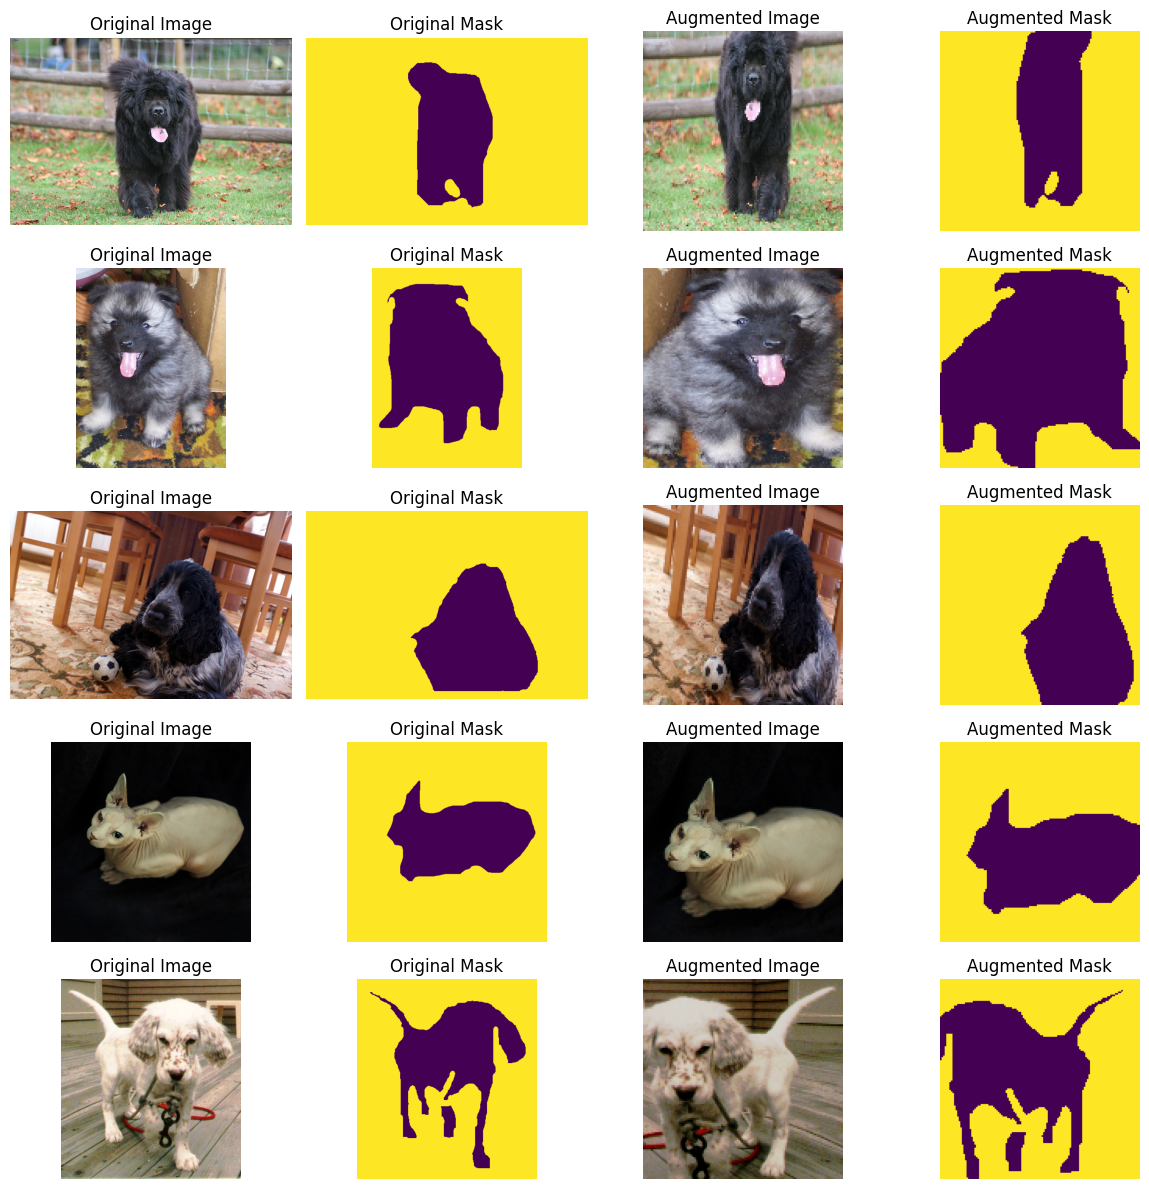

In [17]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
def denormalize(img):
    img = img.permute(1, 2, 0).numpy()
    return (img * std + mean).clip(0, 1)

# Show original and transformed side by side
fig, axs = plt.subplots(5, 4, figsize=(12, 12))

for i in range(5):
    image, mask = dataset[train_indices[i]]
    orig_image = np.array(image)
    orig_mask = convert_mask(mask)

    augmented = train_transform_mod(image=orig_image, mask=orig_mask)
    aug_image = augmented['image']
    aug_mask = augmented['mask']

    axs[i, 0].imshow(orig_image)
    axs[i, 0].set_title("Original Image")
    axs[i, 1].imshow(orig_mask)
    axs[i, 1].set_title("Original Mask")
    axs[i, 2].imshow(denormalize(aug_image))
    axs[i, 2].set_title("Augmented Image")
    axs[i, 3].imshow(aug_mask)
    axs[i, 3].set_title("Augmented Mask")

    for j in range(4):
        axs[i, j].axis('off')

plt.tight_layout()
plt.show()

# 4) Retrain the model

In [15]:
# Simple training loop over 15 epochs (you can increase this number!)
for epoch in range(15):
    model.train()
    running_loss = 0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs[:, 1:2, :, :], masks.unsqueeze(1).float())
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1} | Loss: {running_loss / len(train_loader):.4f}")


Epoch 1 | Loss: 0.2455
Epoch 2 | Loss: 0.0968
Epoch 3 | Loss: 0.0654
Epoch 4 | Loss: 0.0549
Epoch 5 | Loss: 0.0487
Epoch 6 | Loss: 0.0452
Epoch 7 | Loss: 0.0426
Epoch 8 | Loss: 0.0394
Epoch 9 | Loss: 0.0381
Epoch 10 | Loss: 0.0389
Epoch 11 | Loss: 0.0367
Epoch 12 | Loss: 0.0339
Epoch 13 | Loss: 0.0345
Epoch 14 | Loss: 0.0328
Epoch 15 | Loss: 0.0285


# 5) Re-evaluate the model on the test set using IoU and Dice.



Test mIoU: 0.84820556640625
Test Dice: 0.9042835831642151


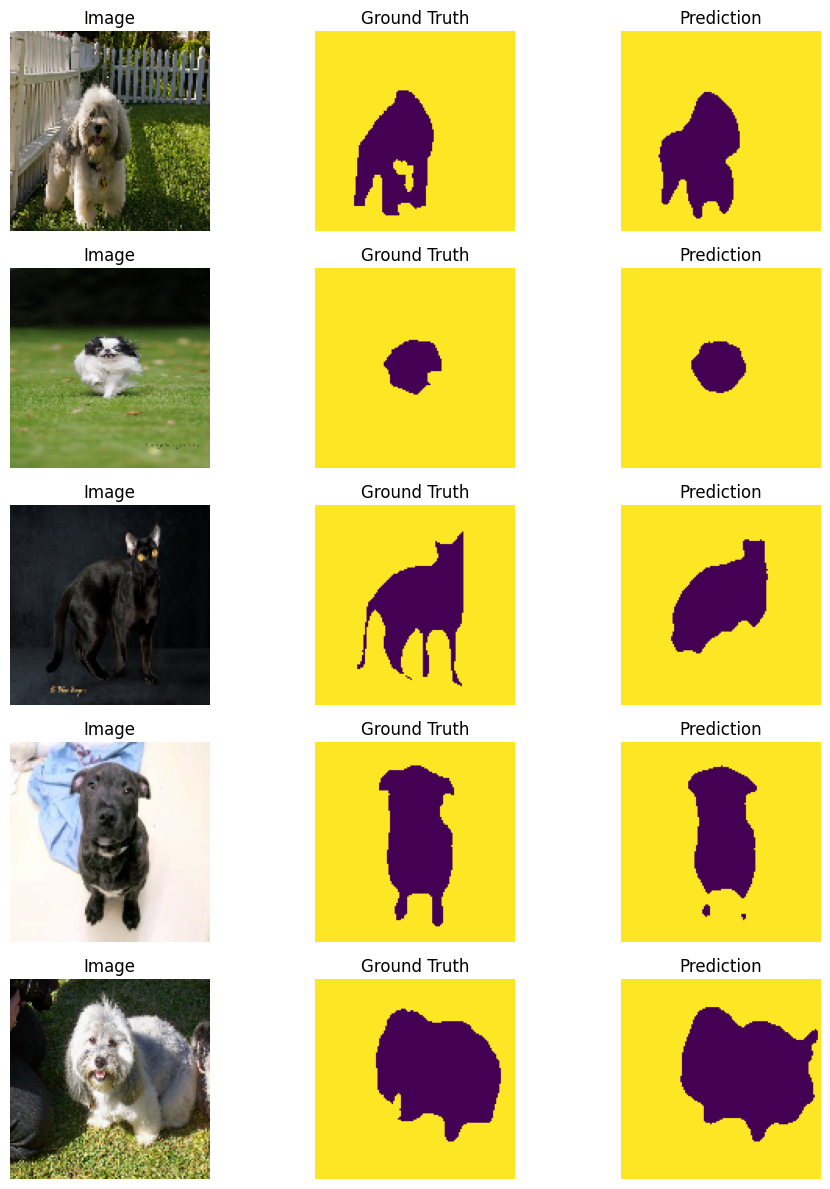

In [20]:
# Evaluate and visualize predictions on a batch of validation data
from torchmetrics import JaccardIndex
from torchmetrics.segmentation import DiceScore

# ======== Creo que podríamos cambiar el task="multiclass" por "binary", debido a que nuestro modelo ahora usa DiceLoss(mode="binary")
iou = JaccardIndex(task="multiclass", num_classes=2, average="macro").to(device)
dice = DiceScore(num_classes=2, average="macro", input_format="index").to(device)

# Evaluation loop
model.eval()
with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        iou.update(preds, masks)
        dice.update(preds, masks)

# Compute and print metrics
print("Test mIoU:", iou.compute().item())
print("Test Dice:", dice.compute().item())


# Visualize predictions from one test batch
# Denormalization helper (already defined earlier)
def denormalize(img):
    img = img.permute(1, 2, 0).cpu().numpy()
    return (img * std + mean).clip(0, 1)

# Take a batch from the test set
images, masks = next(iter(test_loader))
images = images.to(device)
with torch.no_grad():
    outputs = model(images)
preds = torch.argmax(outputs, dim=1).cpu()

# Plot the first 5 examples
fig, axs = plt.subplots(5, 3, figsize=(10, 12))
for i in range(5):
    axs[i, 0].imshow(denormalize(images[i]))
    axs[i, 0].set_title("Image")
    axs[i, 1].imshow(masks[i])
    axs[i, 1].set_title("Ground Truth")
    axs[i, 2].imshow(preds[i])
    axs[i, 2].set_title("Prediction")
    for j in range(3):
        axs[i, j].axis("off")
plt.tight_layout()
plt.show()
